# R2S-26: Transient Modelling

In [2]:
from turborocket.fluids.fluids import IncompressibleFluid
from turborocket.components.fluidics import LiquidValve
import numpy as np
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt



> Author: Elias

> Date: 

## 1 - Introduction

This document describes the transient modelling employed for the OT-2 turbopump. The specific case has been tailored for the R2S-26 testing intended to be performed using water as a working media.

Results from a CFD transient analysis are employed in this document. A pump characteristic is generated based on steady state simulations - with linear interpolation between the evaluated points presented.

## 2 - Pump Characteristic Definition

The points evalauted within the CFD were conducted at a nominal shaft speed of 24k RPM, and are presented below:

In [3]:
H_cfd_points = np.array([470, 480, 505, 550, 545, 250]) # m
W_cfd_points = np.array([12, 13, 18, 23, 35, 45]) # W * m^3 / kg
V_cfd_points = np.array([0, 8, 38, 76, 153, 229]) # lpm
N_cfd = 24000 # rpm

We will define an interpolation function for the pump performances based on these points. The following interpolations are intended to be implemented:

- Simple 2st Order Interpolation for Power
- Quadratic Relation for Head

In [4]:
head_interp = interp1d(x=V_cfd_points, y= H_cfd_points, kind="quadratic")
power_interp = interp1d(x=V_cfd_points, y=W_cfd_points, kind="linear")

A visual representation of these interpolations is presented below:

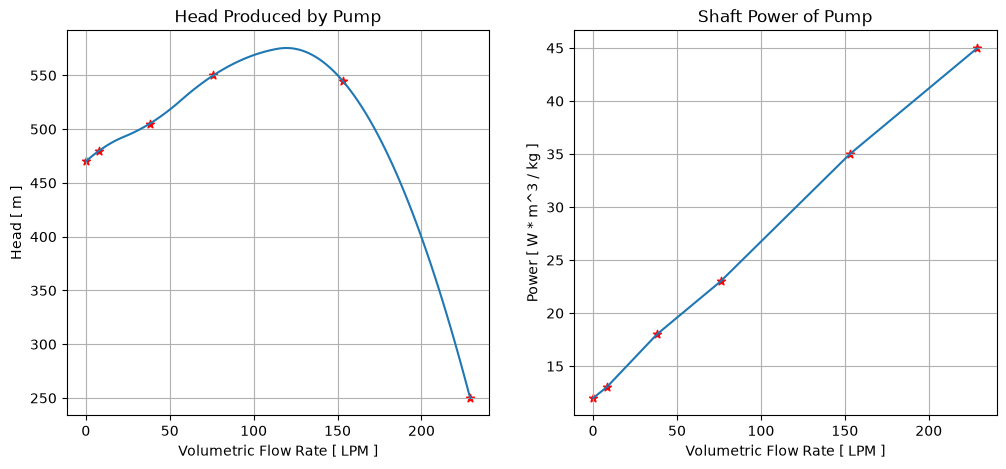

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

V_plot_range = np.linspace(start=V_cfd_points[0], stop=V_cfd_points[-1], num=100)
head_pred = head_interp(V_plot_range)
power_pred = power_interp(V_plot_range)

ax[0].plot(V_plot_range, head_pred)
ax[0].scatter(V_cfd_points, H_cfd_points, marker="*", color="r")
ax[0].set_xlabel("Volumetric Flow Rate [ LPM ]")
ax[0].set_ylabel("Head [ m ]")
ax[0].set_title("Head Produced by Pump")
ax[0].grid()

ax[1].plot(V_plot_range, power_pred)
ax[1].scatter(V_cfd_points, W_cfd_points, marker="*", color="r")
ax[1].set_xlabel("Volumetric Flow Rate [ LPM ]")
ax[1].set_ylabel("Power [ W * m^3 / kg ]")
ax[1].set_title("Shaft Power of Pump")
ax[1].grid()

## 2 - Functions

Using the pump affinity laws, we can define our main function.

In [6]:
def pump_performance( fluid: IncompressibleFluid,
                    N: float,
                    m_dot: float
                    ) -> tuple[float, float]:
    """Function for evaluating the head produced by the pump at a given shaft speed and mass flow rate.

    Args:
        N (float): Shaft Speed [ rad / s ]
        m_dot (float): Mass Flow Rate of fluid through the pump [ kg / s ]
        rho (float, optional): Density of working fluid through the pump. Defaults to 787.

    Returns:
        tuple: Tuple Containing Pump Performance Power  [ Pa ]
    """
    # We firstly evaluate for the voluetric flow rate and shaft speed in nominal units.
    v_dot = (m_dot / fluid.rho) * 1000 * 60

    N *= (60)/(2*np.pi)

    # We then scale up the volumetric flow rate to our nominal flow rate
    v_nom = v_dot * (N_cfd / N)

    # We use this nominal volumetric flow rate to evaluate for our predicted head and shaft power
    
    # We check to see if the normalised value is larger than the max measured using CFD
    if v_nom > V_cfd_points[-1]:
        head_nom = 0
        power_nom = 0.1558 * v_nom + 11.1558
        
    else:
        head_nom = head_interp(v_nom)
        power_nom = power_interp(v_nom)

    # We then scale these values back using our affinity laws back to the original shaft speed.
    head = head_nom * (N / N_cfd)**2
    power = power_nom * (N/N_cfd)**3

    # We can then convert these back to SI units for our working fluid
    head *= fluid.rho * 9.81
    power *= fluid.rho

    # WE can also instantiate a new fluid object downstream
    output = fluid.copy()
    output.update(p=fluid.p + head)

    return (head, power, output)



In [7]:
def d_omega_d_t(tau: float, I:float) -> float:
    """Angular Acceleration of a Shaft
    
    Args:
        tau (float): Shaft Torque [ N m ]
        I (float): Moment of Inertia [ kg m^2 ]

    Returns:
        float: The rate of acceleration of the shaft
    """

    dw_dt = tau / I

    return dw_dt

## 3 - Inputs

The key input for this analysis is an estimate of the turbines performance, along with any parasitic losses. Parasitic losses of the pump assembly have been evaluated based on a preliminary test of the completed assembly.

Torque produced by the turbine is assumed to be approximately constant - which is a reasonable assumption. Torque is back calculated from the turbine power produced using the CFD simulations.

In [8]:
P_cfd_turb = 25.7e3
N_cfd_turb = 24e3 * (2 * np.pi / 60) 
T_turbine = P_cfd_turb / N_cfd_turb

T_parasitic = 0.17

T_available = T_turbine - T_parasitic

print(f"Turbine Produced Torque: {T_turbine:.2f} Nm")
print(f"Turbine Parasitic Losses: {T_parasitic:.2f} Nm")
print(f"Available Shaft Torque: {T_available:.2f} Nm")

Turbine Produced Torque: 10.23 Nm
Turbine Parasitic Losses: 0.17 Nm
Available Shaft Torque: 10.06 Nm


We can also define our incompressible fluid (in this case water).

In [9]:
water = IncompressibleFluid(name="Water", p=14e5, t=295, rho=1000)

We can also define our shaft Inertia.

In [10]:
I = 8e-4 # kg m^2

Finally, we can define our valve with the CdA.

In [11]:
D = 4.0e-3
C_d = 0.8
A = np.pi * (D/2)**2
CdA = C_d * A

valve = LiquidValve(cda=CdA, tau=1, s_pos_init=1)

## 4 - Simulation Setup

We can then setup a simulation accordingly.

In [12]:
dt = 0.001
t_end = 2

t_array = np.arange(0, t_end, dt)

tau_array = [T_available*0.7, T_available, T_available*1.3]

p_in_array = np.zeros(t_array.shape)
p_out_array = np.zeros(t_array.shape)

m_dot_array = np.zeros(t_array.shape)

N_array = np.zeros(t_array.size)

WE can then setup the intial values of the simulation.

In [13]:
p_in = 20e5
p_in_array[0] = p_in
p_out_array[0] = p_in
N_array[0] = 1

We can also define our valve opening sequence

In [14]:
t_open = 1.5

closed_time = np.arange(0, t_open, dt)

closed_act = np.zeros(closed_time.shape)

open_time = np.arange(closed_time[-1] + dt, t_end, dt)

open_act = np.ones(open_time.shape)

valve_sequence = np.concatenate([closed_act, open_act])

We can then define our turbine performance 

In [26]:
tau_turbine = 12 # Nm

## 5 - Simulation Results

We can conduct our for loop accordingly.

In [27]:
for idx, val in np.ndenumerate(t_array):
    p_in_array[idx] = p_in

    # We just need to set the pressure
    water.update(p=p_in_array[idx]) 
    
    # We get the performance parameters of the pump
    head, power, fluid_out = perf = pump_performance(fluid=water, N= N_array[idx], m_dot=m_dot_array[idx])

    # We then evaluate for the mass flow through the orifice
    m_dot_array[idx[0]+1] = abs(valve.get_mdot(upstr=water, downstr=fluid_out, dt=dt))

    T_av = tau_turbine - (power / N_array[idx])

    # We then get the expected acceleration of the turbine
    dw_dt = d_omega_d_t(tau=T_av, I=I)
    # We can then evaluate for the next shaft speed
    N_array[idx[0]+1] = N_array[idx] + dw_dt * dt

    # We store the rest of our parameters
    p_out_array[idx[0]+1] = fluid_out.p


IndexError: index 2000 is out of bounds for axis 0 with size 2000

In [ ]:
dp_dt_array = np.gradient(p_out_array, t_array)

(0.0, 2.0)

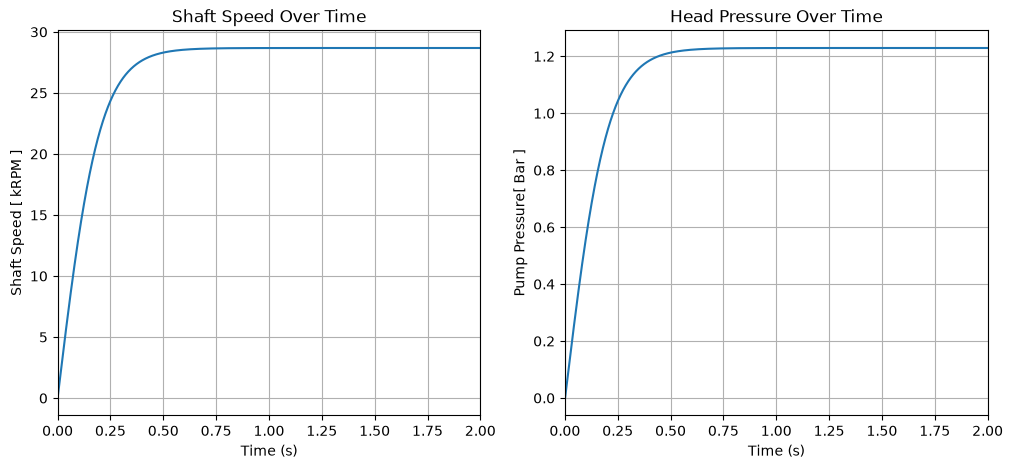

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(t_array, N_array * 60 / (2* np.pi) / 1e3)
ax[0].set_title(f"Shaft Speed Over Time")
ax[0].set_xlabel(f"Time (s)")
ax[0].set_ylabel(f"Shaft Speed [ kRPM ]")
ax[0].grid()
ax[0].set_xlim([0, t_end])

ax[1].plot(t_array, m_dot_array)
ax[1].set_title(f"Head Pressure Over Time")
ax[1].set_xlabel(f"Time (s)")
ax[1].set_ylabel(f"Pump Pressure[ Bar ]")
ax[1].grid()
ax[1].set_xlim([0, t_end])




(0.0, 2.0)

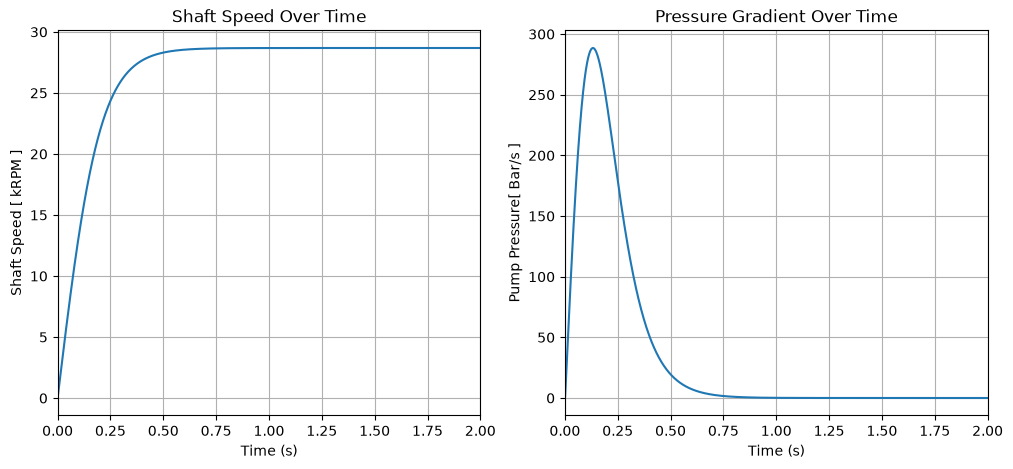

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(t_array, N_array * 60 / (2* np.pi) / 1e3)
ax[0].set_title(f"Shaft Speed Over Time")
ax[0].set_xlabel(f"Time (s)")
ax[0].set_ylabel(f"Shaft Speed [ kRPM ]")
ax[0].grid()
ax[0].set_xlim([0, t_end])

ax[1].plot(t_array, dp_dt_array/1e5)
ax[1].set_title(f"Pressure Gradient Over Time")
ax[1].set_xlabel(f"Time (s)")
ax[1].set_ylabel(f"Pump Pressure[ Bar/s ]")
ax[1].grid()
ax[1].set_xlim([0, t_end])




In [45]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram
import tempfile
import os


def mp4_to_spectrogram(mp4_file, output_png="spectrogram.png"):
    # Create temporary WAV
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        wav_file = tmp.name

    try:
        # Extract audio with ffmpeg
        subprocess.run([
            "ffmpeg",
            "-y",
            "-i", mp4_file,
            "-vn",
            "-ac", "1",        # mono
            "-ar", "44100",    # sample rate
            wav_file
        ], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # Read WAV
        sample_rate, audio = wavfile.read(wav_file)

        # Convert to float if needed
        if audio.dtype != np.float32 and audio.dtype != np.float64:
            audio = audio.astype(np.float32)
            audio /= np.iinfo(np.int16).max

        # Compute spectrogram
        f, t, Sxx = spectrogram(
            audio,
            fs=sample_rate,
            window="hann",
            nperseg=2048,
            noverlap=1536,
            scaling="density",
            mode="magnitude"
        )

        # Convert to dB
        Sxx_db = 20 * np.log10(Sxx + 1e-10)

        # Plot
        plt.figure(figsize=(12, 6))
        plt.pcolormesh(t, f, Sxx_db, shading="gouraud", cmap="magma")
        plt.ylabel("Frequency (Hz)")
        plt.xlabel("Time (s)")
        plt.yscale("log")
        plt.colorbar(label="Magnitude (dB)")
        plt.tight_layout()
        plt.savefig(output_png, dpi=300)
        plt.close()

        print(f"Saved to {output_png}")

    finally:
        os.remove(wav_file)


if __name__ == "__main__":
    mp4_to_spectrogram("input.mp4")

Saved to spectrogram.png
